In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Set matplotlib to show plots inline
%matplotlib inline

# Load the dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
print("Loading data...")
df = pd.read_csv(url)

# Clean column names (lowercase to camelcase)
rename_dict = {col: col.capitalize() for col in df.columns if col.lower() in ["radio", "newspaper", "sales"]}
rename_dict['tv'] = 'TV'
df = df.rename(columns=rename_dict)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Data loaded successfully!")
df.head()

Loading data...
Data loaded successfully!


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


Null Values Check:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


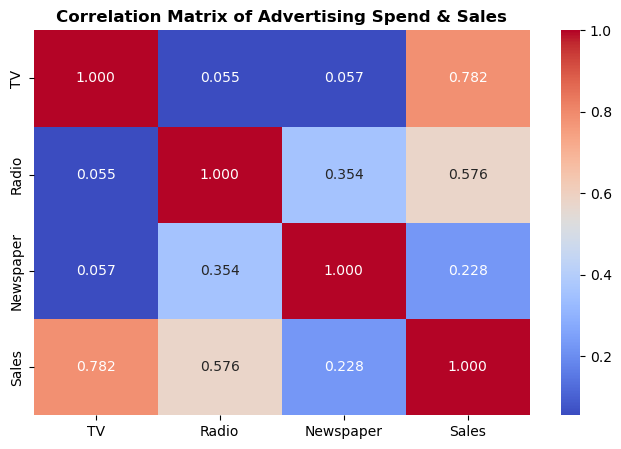

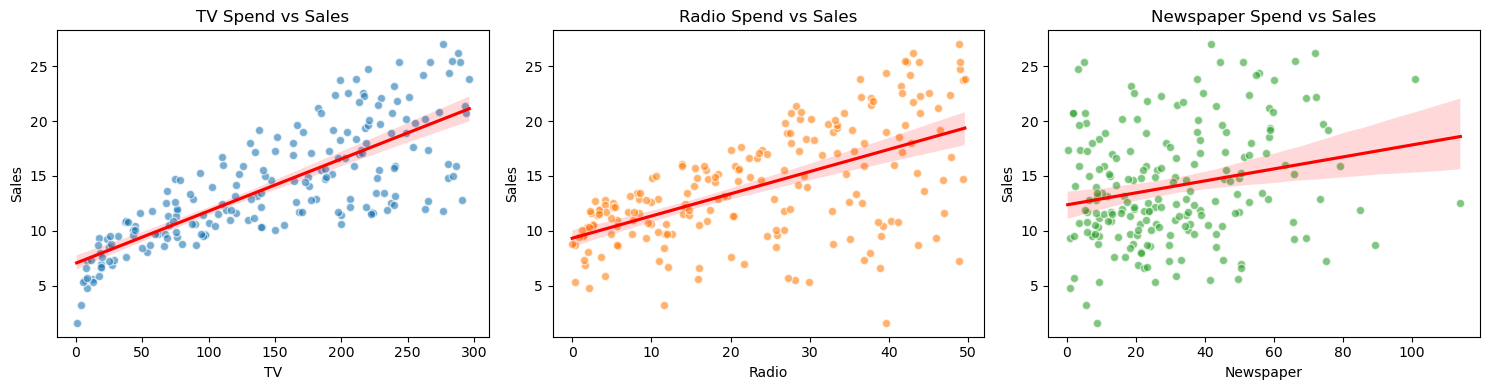

In [2]:
# Check for nulls
print("Null Values Check:")
print(df.isnull().sum())

# Correlation matrix heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Matrix of Advertising Spend & Sales", fontweight="bold")
plt.show()

# Pairwise scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ["TV", "Radio", "Newspaper"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, col in enumerate(features):
    sns.regplot(data=df, x=col, y="Sales", ax=axes[i], color=colors[i], 
                scatter_kws={"alpha":0.6, "edgecolor":"w"}, line_kws={"color":"red"})
    axes[i].set_title(f"{col} Spend vs Sales")
plt.tight_layout()
plt.show()

In [3]:
# Splitting features and target
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate Models
print("--- Linear Regression ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"R2 Score: {r2_score(y_test, y_pred_lr):.3f}")

print("\n--- Random Forest Regressor ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf):.3f}")

# Save the trained model assets
joblib.dump(rf, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nBest model (Random Forest) saved!")

--- Linear Regression ---
MAE: 1.461
R2 Score: 0.899

--- Random Forest Regressor ---
MAE: 0.621
R2 Score: 0.981

Best model (Random Forest) saved!


Return per Standard Deviation Spend (Linear Regression Coefficients):


,Feature,Coefficient
0,TV,3.764196
1,Radio,2.792307
2,Newspaper,0.055976



Relative Feature Importance (Random Forest):


,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


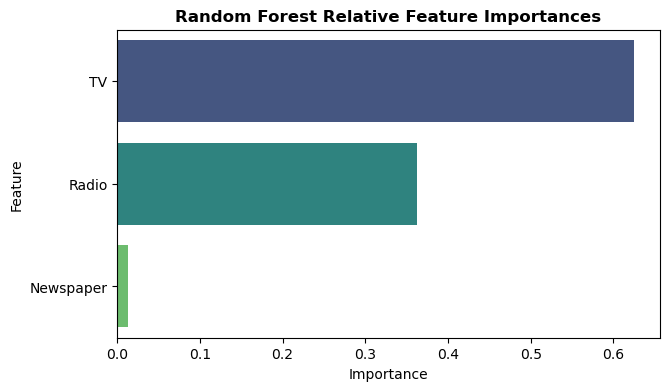

In [4]:
# 1. Linear regression coefficients
coef_df = pd.DataFrame({"Feature": features, "Coefficient": lr.coef_}).sort_values(by="Coefficient", ascending=False)
print("Return per Standard Deviation Spend (Linear Regression Coefficients):")
display(coef_df)

# 2. Random Forest feature importance
importances_df = pd.DataFrame({"Feature": features, "Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False)
print("\nRelative Feature Importance (Random Forest):")
display(importances_df)

# Bar chart of Random Forest importances (Warning-free version)
plt.figure(figsize=(7, 4))
sns.barplot(
    data=importances_df, 
    x="Importance", 
    y="Feature", 
    hue="Feature", 
    palette="viridis", 
    legend=False
)
plt.title("Random Forest Relative Feature Importances", fontweight="bold")
plt.show()

In [5]:
# Run this cell to input custom budget values and get a real-time prediction
print("Enter planned advertising budget to predict Sales:")
try:
    tv_input = float(input("Planned TV budget ($): "))
    radio_input = float(input("Planned Radio budget ($): "))
    news_input = float(input("Planned Newspaper budget ($): "))
    
    # Wrap inputs in a DataFrame with matching column names to prevent warnings
    input_data = pd.DataFrame({
        "TV": [tv_input],
        "Radio": [radio_input],
        "Newspaper": [news_input]
    })
    
    # Scale input and predict
    scaled_input = scaler.transform(input_data)
    predicted_sales = rf.predict(scaled_input)[0]
    
    print("\n" + "="*30)
    print(f"Predicted Sales: ${predicted_sales:,.2f}")
    print("="*30)
except Exception as e:
    print(f"Error: Make sure you input valid numbers. Details: {e}")

Enter planned advertising budget to predict Sales:


Planned TV budget ($):  150
Planned Radio budget ($):  25
Planned Newspaper budget ($):  10



Predicted Sales: $15.22
